In [94]:
import numpy as np
cau = [
    "Tôi yêu Bách Khoa và đam mê lập trình Python",
    "Sinh viên HCMUT thức đêm cày deadline AI",
    "Lab EE_MLIOT là nơi hội tụ các chiến thần học máy",
    "Hôm nay trời nắng gắt nhưng tôi vẫn phải đi học",
    "Con mèo lười đang ngủ say sưa bên cạnh chú chó",
    "Một ngày tôi uống đủ 2 lít nước để tỉnh táo code",
    "Tiền điện tháng này tăng mạnh vì cắm máy train model",
    "Tôi thích ăn phở bò Bách Khoa vào mỗi buổi sáng",
    "Lập trình viên hướng nội thường sợ giao tiếp đám đông",
    "Trí tuệ nhân tạo đang thay đổi thế giới từng ngày"
]

In [95]:
vocab = sorted({w for str in cau for w in str.lower().split()})
print(len(vocab))

95


In [96]:
def to_vector(s):
    v = np.zeros(len(vocab))
    for x in s.lower().split():
        if x in vocab: #Check từ mới
            v[vocab.index(x)] += 1
    return v


# 3.1

In [97]:
X = np.array([to_vector(s) for s in cau])
print(X.shape)

(10, 95)


X có 10 hàng (số lượng câu) và 95 cột (số lượng từ phân biệt có trong các câu)

In [98]:
X_mean = X.mean(axis = 0)
X_mean

array([0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.2,
       0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.4, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
       0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.1,
       0.1, 0.1, 0.1, 0.1])

In [99]:
X_centered = X - X_mean
X_centered

array([[-0.1, -0.1, -0.1,  0.8, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.2, -0.1,  0.8, -0.1, -0.1, -0.1, -0.1,  0.8, -0.1, -0.2,
        -0.1,  0.9, -0.1, -0.1, -0.1, -0.1, -0.2, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,  0.9, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,
         0.8, -0.1, -0.1, -0.1, -0.1,  0.6, -0.1, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.2,  0.9, -0.1, -0.1, -0.1,  0.9, -0.1,  0.9, -0.2, -0.1,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1],
       [-0.1,  0.9, -0.1, -0.2, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,
         0.9, -0.1, -0.1, -0.1,  0.9, -0.1, -0.1, -0.1, -0.1,  0.9, -0.1,
        -0.1, -0.2, -0.1, -0.2, -0.1, -0.1, -0.1, -0.1, -0.2, -0.1, -0.2,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.2, -0.1, -0.1, -0.1, -0.1,
        -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1,  0.9,

In [100]:
print("Shape của ma trận X", X.shape)
print("Shape vector trung bình X_mean:", X_mean.shape)
print("Shape ma trận sau khi trừ trung bình:", X_centered.shape)

Shape của ma trận X (10, 95)
Shape vector trung bình X_mean: (95,)
Shape ma trận sau khi trừ trung bình: (10, 95)


In [101]:
def cosine_similarity (X, Y= None ):
    if Y is None :
        Y = X
    Xn = X / np. linalg . norm (X, axis =1, keepdims = True )
    Yn = Y / np. linalg . norm (Y, axis =1, keepdims = True )
    return Xn @ Yn.T # ma tran tuong dong


In [102]:
#TODO : viet ham search (query , top_k =3) tra ve top_k muc giong nhat
def search(query, top_k = 8):

    v = to_vector(query)
    if np.sum(v) == 0:
        print(f"Không tìm thấy từ nào trong câu '{query}' thuộc từ điển hiện tại")
        print("Vui lòng thử lại với các từ khóa khác.")
        return []
    v = v.reshape(1, -1)
    cs = cosine_similarity(X, v).flatten()
    sorted_cs = np.argsort(-cs)
    print(f"{top_k} mục giống nhất của {query}:")
    for i in sorted_cs[:top_k]:
        print(f"{cau[i]}, cosine_similarity= {cs[i]}")
    

search("Hôm nay tôi muốn ăn tô phở bò thật to")

8 mục giống nhất của Hôm nay tôi muốn ăn tô phở bò thật to:
Tôi thích ăn phở bò Bách Khoa vào mỗi buổi sáng, cosine_similarity= 0.492365963917331
Hôm nay trời nắng gắt nhưng tôi vẫn phải đi học, cosine_similarity= 0.36927447293799825
Tôi yêu Bách Khoa và đam mê lập trình Python, cosine_similarity= 0.12909944487358058
Một ngày tôi uống đủ 2 lít nước để tỉnh táo code, cosine_similarity= 0.11785113019775795
Lab EE_MLIOT là nơi hội tụ các chiến thần học máy, cosine_similarity= 0.0
Sinh viên HCMUT thức đêm cày deadline AI, cosine_similarity= 0.0
Con mèo lười đang ngủ say sưa bên cạnh chú chó, cosine_similarity= 0.0
Tiền điện tháng này tăng mạnh vì cắm máy train model, cosine_similarity= 0.0


Như vậy ta thấy với input là "Hôm nay tôi muốn ăn tô phở bò thật to", hàm search cho câu giống nhất là câu:  
Tôi thích ăn phở bò Bách Khoa vào mỗi buổi sáng, cosine_similarity= 0.492365963917331    
Có 4 câu không giống gì nhất đó là:  
Lab EE_MLIOT là nơi hội tụ các chiến thần học máy, cosine_similarity= 0.0  
Sinh viên HCMUT thức đêm cày deadline AI, cosine_similarity= 0.0  
Con mèo lười đang ngủ say sưa bên cạnh chú chó, cosine_similarity= 0.0  
Tiền điện tháng này tăng mạnh vì cắm máy train model, cosine_similarity= 0.0  
Kết quả hoàn toàn khớp trực giác

# 3.2

In [104]:
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
print("Shape của U: ", U.shape)
print("Shape của S: ", S.shape)
print("Shape của Vt:", Vt.shape)

Shape của U:  (10, 10)
Shape của S:  (10,)
Shape của Vt: (10, 95)


In [107]:
X_2d = U[:, :2] * S[:2]

print("Kích thước ma trận tọa độ 2D mới:", X_2d.shape)

Kích thước ma trận tọa độ 2D mới: (10, 2)


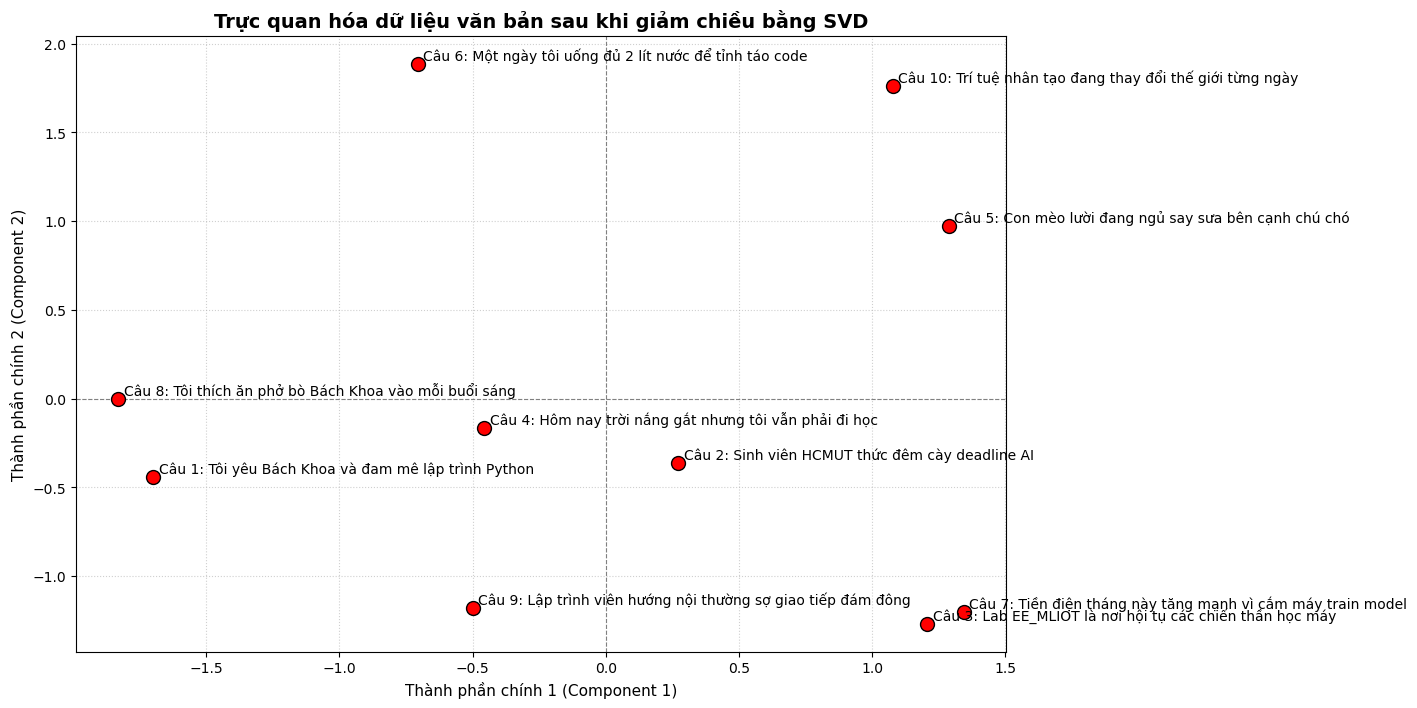

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8), dpi=100)

x_coords = X_2d[:, 0]
y_coords = X_2d[:, 1]
plt.scatter(x_coords, y_coords, color='red', edgecolors='black', s=100, zorder=3)

for i, text in enumerate(cau):
    plt.text(x_coords[i] + 0.02, y_coords[i] + 0.02, f"Câu {i+1}: {text}", 
             fontsize=10, family='sans-serif')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Trục hoành
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Trục tung
plt.title("Trực quan hóa dữ liệu văn bản sau khi giảm chiều bằng SVD", fontsize=14, fontweight='bold')
plt.xlabel("Thành phần chính 1 (Component 1)", fontsize=11)
plt.ylabel("Thành phần chính 2 (Component 2)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Sự phân cụm (Clustering): Các câu có chung chủ đề thường sẽ nằm gần nhau trên đồ thị.  
Các câu về công nghệ/học tập (Câu 1, 2, 3, 4, 7, 9) có xu hướng tụ lại thành một nhóm. Câu về thú cưng (Câu 5) hoặc ăn uống (Câu 8, 6) sẽ đứng tách biệt ở các góc khác.  
Ý nghĩa của việc giảm chiều: SVD đã nén thành công thông tin từ một ma trận thưa (nhiều số 0 của Bag-of-Words) về dạng tọa độ phẳng gọn gàng mà vẫn giữ được khoảng cách ngữ nghĩa tương đối giữa các câu.  